In [ ]:
pip install natasha

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.1 MB/s eta 0:00:00
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26098 sha256=bbb83203c3971792d722d798df1bde60eb87af6924cb2aa8200d2a63dd1cbb89
  Stored in directory: /root/.cache/pip/wheels/65/c3/c3/238bf93c243597857edd94ddb0577faa74a8e16e9585896e83
Successfully built intervaltree


In [ ]:
from collections import Counter
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from natasha import (
    Doc, Segmenter, MorphVocab,
    NewsEmbedding, NewsMorphTagger
)
import plotly.express as px
import pandas as pd

In [ ]:
with open('perazki1.txt') as file1:
  text = file1.read()

Задание 1

In [ ]:
stihi = text.split('\n\n')

In [ ]:
stihi[-1]
stihi.remove('')

In [ ]:
stihi[-1]

'свинья везде найдет работу\nответил мне гиппопатам\nи вздор задумчивый направил\nкудато в сторону болот'

In [ ]:
len(stihi) # кол-во стихов

38070

Задание 2

In [ ]:
letters = text.strip().split()
count = Counter(letters)
top_20 = count.most_common(50)

In [ ]:
top_20

[('и', 29939),
 ('в', 22026),
 ('не', 13506),
 ('на', 12651),
 ('я', 11020),
 ('а', 10740),
 ('с', 7208),
 ('что', 6028),
 ('как', 5432),
 ('но', 4005),
 ('у', 3600),
 ('олег', 3591),
 ('он', 3490),
 ('ты', 3467),
 ('по', 3436),
 ('мне', 3332),
 ('за', 3316),
 ('из', 3186),
 ('то', 3070),
 ('к', 2999),
 ('когда', 2705),
 ('вот', 2182),
 ('все', 2162),
 ('мы', 2077),
 ('так', 1993),
 ('меня', 1981),
 ('от', 1931),
 ('всё', 1658),
 ('сказал', 1615),
 ('это', 1589),
 ('его', 1571),
 ('под', 1515),
 ('чтоб', 1473),
 ('нет', 1383),
 ('там', 1369),
 ('оксана', 1348),
 ('для', 1295),
 ('о', 1251),
 ('кто', 1232),
 ('уже', 1219),
 ('же', 1197),
 ('потом', 1186),
 ('где', 1149),
 ('вы', 1144),
 ('есть', 1098),
 ('до', 1079),
 ('она', 1071),
 ('их', 1064),
 ('был', 1062),
 ('только', 1042)]

Задание 3

In [ ]:
stop_words = {
    "и", "в", "во", "не", "на", "я", "мы", "ты", "вы", "он", "она", "они",
    "что", "как", "к", "с", "со", "а", "но", "да", "или",
    "от", "до", "за", "по", "о", "об", "при",
    "у", "из", "над", "под", "же", "ли", "бы", 'вдруг'
}
souzhi = {
    "и", "да", "ни", "тоже", "также", "как", "ни", "то", "другое",
    "а", "но", "однако", "зато", "же", "лишь", "только",
    "или", "либо", "то", "не", "или",
    "что", "чтобы", "как", "когда", "если", "потому", "так",
    "хотя", "будто", "чем", "ли", "пока", "раз", "чем", "тем", 'чтоб'
}
mats = ("ху", "бля", "пизд", "наху", "еб", "наеб", "выеб", "говн")


In [ ]:
infromation_letters = [word for word in letters if word not in stop_words and word not in souzhi and len(word) > 3 and not word.startswith(mats)]

In [ ]:
count_information = Counter(infromation_letters)
top_20_information = count_information.most_common(20)

In [ ]:
top_20_information

[('олег', 3591),
 ('меня', 1981),
 ('сказал', 1615),
 ('оксана', 1348),
 ('потом', 1186),
 ('есть', 1098),
 ('теперь', 954),
 ('тебя', 857),
 ('день', 801),
 ('аркадий', 800),
 ('сегодня', 715),
 ('себя', 676),
 ('тебе', 674),
 ('себе', 660),
 ('просто', 654),
 ('говорит', 629),
 ('люди', 615),
 ('всех', 611),
 ('глаза', 605),
 ('олега', 604)]

Задание 4

In [ ]:
pattern = r"\bОлег[а-яёА-ЯЁ]*\b[\s,.:!?-]*([а-яёА-ЯЁ]+)"
words_after_oleg = re.findall(pattern, text, flags=re.IGNORECASE)
words_after_oleg

['распахивает',
 'потом',
 'еще',
 'и',
 'потеет',
 'один',
 'сидящий',
 'несёт',
 'не',
 'уволился',
 'окоченевший',
 'не',
 'тихонько',
 'уже',
 'открыт',
 'петрович',
 'а',
 'за',
 'не',
 'заходит',
 'с',
 'из',
 'работал',
 'запнулся',
 'вы',
 'весной',
 'с',
 'внезапно',
 'а',
 'всегда',
 'в',
 'молчал',
 'но',
 'давал',
 'нет',
 'прикинулся',
 'был',
 'проснулся',
 'почки',
 'я',
 'бежит',
 'николай',
 'сначала',
 'ухода',
 'раскроили',
 'славу',
 'включает',
 'был',
 'собралса',
 'проснулся',
 'курил',
 'кончались',
 'хотел',
 'приходит',
 'раздевайтесь',
 'дантисту',
 'там',
 'дантисту',
 'за',
 'не',
 'показывая',
 'приедь',
 'любил',
 'наверняка',
 'откуда',
 'надел',
 'возьми',
 'не',
 'тонул',
 'идёт',
 'голос',
 'включает',
 'списаны',
 'а',
 'вы',
 'любил',
 'петрович',
 'у',
 'выходит',
 'наверно',
 'оксану',
 'нагнулся',
 'проснулся',
 'включает',
 'всю',
 'грубо',
 'не',
 'расстался',
 'решил',
 'плохой',
 'сказал',
 'услышав',
 'о',
 'жыл',
 'плохо',
 'мама',
 'часто'

Задание 5

In [ ]:
text_for_cloud = " ".join(words_after_oleg)

In [ ]:
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color="white"
).generate(text_for_cloud)

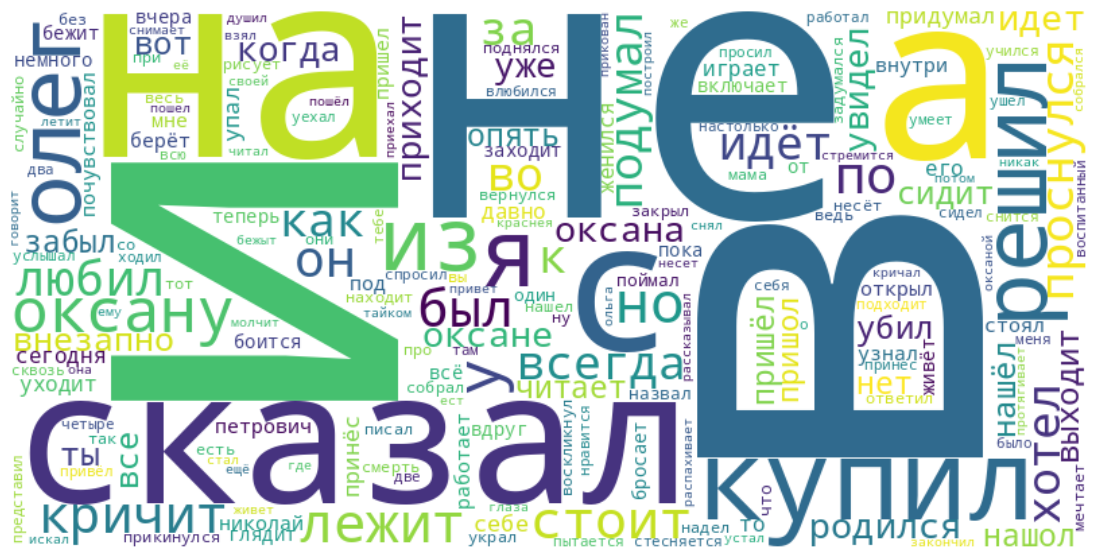

In [ ]:
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Задание 6

In [ ]:
stihi[:2] # список stihi

['а где тут руль спросил гагарин\nдеревня буркнул королёв\nещё спроси а где тут вожжи\nещё поехали скажи',
 'вот позитивный анатолий\nбыл послан нахуй но сумел\nвернуться бодрым отдохнувшим\nи два магнитика привез']

Задание 7

In [ ]:
stihi_filtered = []
for v in stihi:
  words = v.strip().split()
  filtered_words = [word for word in words if word not in stop_words and word not in souzhi and len(word) > 3 and not word.startswith(mats)]
  stihi_filtered.append(' '.join(filtered_words))

Задание 8

In [ ]:
vectorizer = CountVectorizer(min_df=4)
X = vectorizer.fit_transform(stihi_filtered)

In [ ]:
words = vectorizer.get_feature_names_out()
print("Слова:", words)
print("Матрица:")
print(X.toarray())


Слова: ['абонемент' 'аборт' 'абортарий' ... 'ёлки' 'ёлкой' 'ёлку']
Матрица:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
X.toarray().shape

(38070, 17192)

Задание 9

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

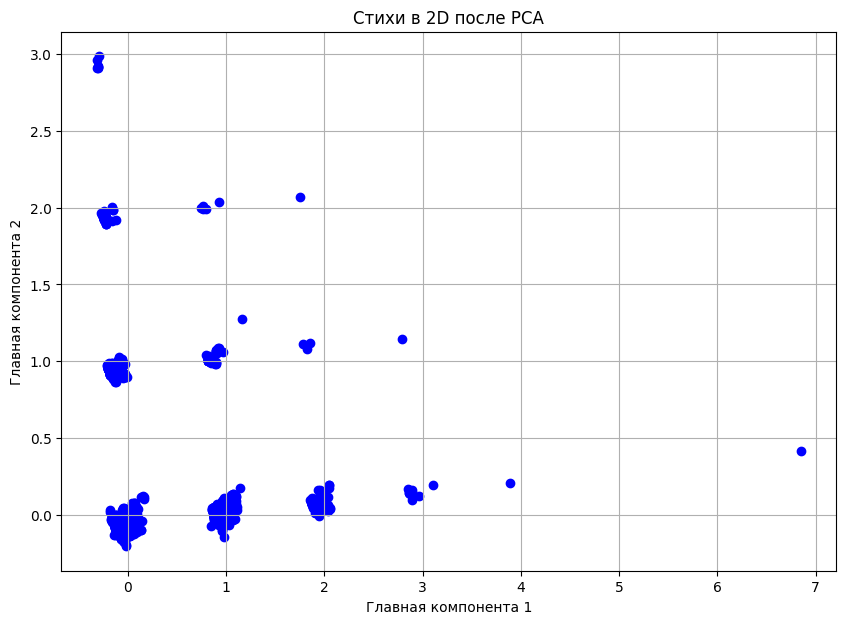

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue')
plt.title("Стихи в 2D после PCA")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.grid(True)

Задание 10

In [ ]:
adjectives_per_stih = []
emb = NewsEmbedding()
segmenter = Segmenter()
morph_vocab = MorphVocab()
morph_tagger = NewsMorphTagger(emb)
for v in stihi:
    doc = Doc(v)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    adjectives = [token.text for token in doc.tokens if token.pos == "ADJ"]
    adjectives_per_stih.append(adjectives)

In [ ]:
adjectives_per_stih

[['буркнул', 'спроси'],
 ['позитивный', 'бодрым', 'отдохнувшим'],
 ['тёмном', 'распахивает', 'второй', 'третий'],
 [],
 ['понятно', 'волшебный'],
 ['ролевые'],
 [],
 ['искусствоведов', 'седой', 'строгий'],
 ['любимый'],
 ['покосившемся'],
 ['простая'],
 ['остальными'],
 ['пустую', 'старую'],
 ['рудименты'],
 ['зависимы', 'прочих', 'свиньи'],
 ['зачеркивает'],
 ['родной'],
 [],
 ['бессмертны'],
 ['должно', 'кулакам'],
 ['ужели', 'ледяной'],
 ['зеленый'],
 [],
 [],
 ['оконного'],
 [],
 ['готов'],
 ['самого'],
 ['перезвони'],
 [],
 [],
 ['скребутся'],
 [],
 ['выебем', 'донесся'],
 ['чисть'],
 ['простым', 'коротким', 'красивым', 'длинным'],
 [],
 ['ценные'],
 ['эргономичные', 'сплошные', 'неудобный', 'острый'],
 ['непомытою', 'крайней'],
 ['грядут', 'большие', 'соседней', 'дружеской'],
 ['березовом', 'раскинув'],
 ['полночный', 'беззвучном', 'фонарей'],
 ['великий'],
 [],
 ['шевельнуло'],
 ['пивной'],
 ['грача'],
 [],
 [],
 [],
 ['остальное', 'романс'],
 [],
 ['собственная'],
 [],
 [],
 []

In [ ]:
import plotly.express as px
import pandas as pd
labels = [" ".join(adj_list) if adj_list else "—" for adj_list in adjectives_per_stih]
df = pd.DataFrame({
    'Главная компонента 1': X_pca[:,0],
    'Главная компонента 2': X_pca[:,1],
    'label': labels
})
fig = px.scatter(df, x='Главная компонента 1', y='Главная компонента 2', hover_name='label', title = 'Стихи в 2D, подписанные прилагательными')
fig.show()